# 08B: DIJKSTRA HOTTEST ROUTE (SHARED MODEL APPROACH)

This notebook finds the HOTTEST pedestrian route using Dijkstra's algorithm with a raster-only cost surface. The shared model approach uses only the deployment model (raster features) for uniform coverage across the entire study area.

## MODULE SETUP

In [4]:
# Mount Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

# Set working directory to project folder.
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/hot_hem"
os.chdir(BASE_DIR)

print(f"Working directory: {BASE_DIR}")

Working directory: /content/drive/MyDrive/Colab Notebooks/hot_hem


## IMPORT SETUP

In [6]:
! pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 8.2 MB/s eta 0:00:00


In [7]:
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import rasterio
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from scipy.interpolate import griddata
import networkx as nx
import osmnx as ox
from shapely.geometry import Point, LineString, box

## PATH CONFIGURATION

In [8]:
# Input paths.
BOUNDARY_FILE = Path("data/inputs/boundaries/aoi_wards.geojson")
NETWORK_FILE = Path("data/processing/network/network.graphml")
DEPLOYMENT_MODEL_FILE = Path("models/xgboost_deployment_model.pkl")
NETWORK_FEATURES_FILE = Path("data/outputs/features/network_nodes_with_raster_features.csv")

# Check if raster already exists from 08a.
PRED_RASTER_ONLY = Path("data/outputs/routing/pred_raster_only.tif")

# Output paths.
OUT_DIR = Path("data/outputs/routing")
OUT_DIR.mkdir(parents = True, exist_ok = True)

COST_SURFACE = OUT_DIR / "cost_surface_shared.tif"
HOTTEST_ROUTE = OUT_DIR / "hottest_route_shared.geojson"

print("PATH CONFIGURATION")
print(f"Boundary file: {BOUNDARY_FILE}")
print(f"Network file: {NETWORK_FILE}")
print(f"Output directory: {OUT_DIR}")

PATH CONFIGURATION
Boundary file: data/inputs/boundaries/aoi_wards.geojson
Network file: data/processing/network/network.graphml
Output directory: data/outputs/routing


## LOAD STUDY AREA BOUNDARIES

In [9]:
# Load ward boundaries.
gdf_wards = gpd.read_file(BOUNDARY_FILE)

print(f"Loaded {len(gdf_wards)} ward boundaries.")
print(f"Columns: {list(gdf_wards.columns)}")
print(f"CRS: {gdf_wards.crs}")
gdf_wards.head()

Loaded 37 ward boundaries.
Columns: ['OBJECTID', 'COUNTRY', 'ENGNAME', 'NAME_1', 'ENGNAME_1', 'NAME_2', 'ENGNAME_2', 'NAME_3', 'ENGNAME_3', 'TYPE_3', 'ENGTYPE_3', 'Shape_Length', 'Shape_Area', 'geometry']
CRS: EPSG:4326


,OBJECTID,COUNTRY,ENGNAME,NAME_1,ENGNAME_1,NAME_2,ENGNAME_2,NAME_3,ENGNAME_3,TYPE_3,ENGTYPE_3,Shape_Length,Shape_Area,geometry
0,4644,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Bến Nghé,Ben Nghe,Phường,Ward,0.064065,0.000204,"POLYGON ((106.70944 10.78751, 106.70921 10.787..."
1,4645,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Bến Thành,Ben Thanh,Phường,Ward,0.038229,0.000077,"POLYGON ((106.69501 10.77958, 106.68721 10.771..."
2,4646,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cầukho,Caukho,Phường,Ward,0.022276,0.000028,"POLYGON ((106.68813 10.75439, 106.68875 10.754..."
3,4647,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cầu Ông Lãnh,Cau Ong Lanh,Phường,Ward,0.017988,0.000018,"POLYGON ((106.69755 10.7624, 106.69792 10.7629..."
4,4648,Việt Nam,Vietnam,Hồ Chí Minh,Ho Chi Minh,Quận 1,District 1,Cô Giang,Co Giang,Phường,Ward,0.023104,0.000030,"POLYGON ((106.69269 10.75825, 106.69449 10.759..."


In [10]:
# Get study area bounds.
total_bounds = gdf_wards.total_bounds
minx, miny, maxx, maxy = total_bounds

print("STUDY AREA BOUNDS")
print(f"Min X (lon): {minx:.6f}")
print(f"Max X (lon): {maxx:.6f}")
print(f"Min Y (lat): {miny:.6f}")
print(f"Max Y (lat): {maxy:.6f}")

STUDY AREA BOUNDS
Min X (lon): 106.594556
Max X (lon): 106.810093
Min Y (lat): 10.689854
Max Y (lat): 10.819768


## VISUALIZE STUDY AREA

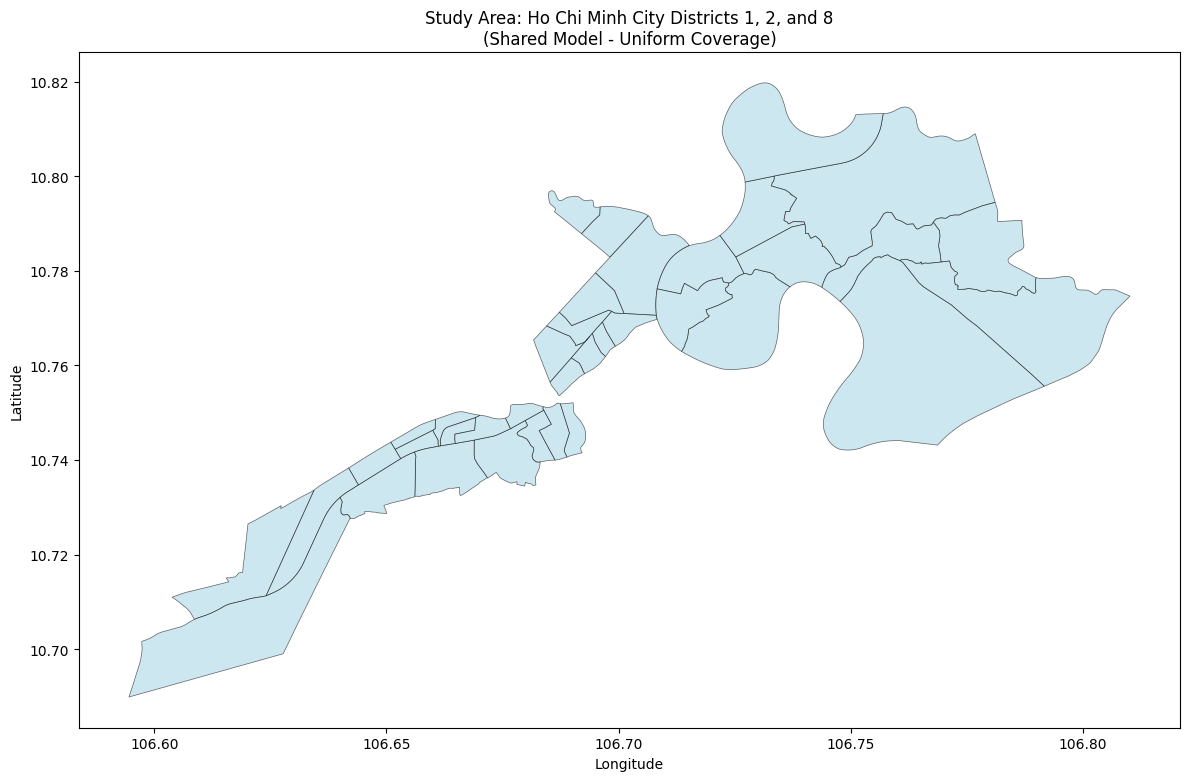

In [11]:
# Create study area visualization.
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Identify district column.
district_col = None
for col in ["district", "District", "quan", "ten_quan"]:
    if col in gdf_wards.columns:
        district_col = col
        break

# Plot wards colored by district.
if district_col:
    gdf_wards.plot(
        ax = ax,
        column = district_col,
        cmap = "Set3",
        edgecolor = "black",
        linewidth = 0.5,
        alpha = 0.6,
        legend = True,
        legend_kwds = {"title": "District", "loc": "upper right"}
    )
else:
    gdf_wards.plot(
        ax = ax,
        facecolor = "lightblue",
        edgecolor = "black",
        linewidth = 0.5,
        alpha = 0.6
    )

# Identify ward column.
ward_col = None
for col in ["ward", "Ward", "name", "NAME", "ten_phuong"]:
    if col in gdf_wards.columns:
        ward_col = col
        break

# Add ward labels.
if ward_col:
    for idx, row in gdf_wards.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(
            row[ward_col],
            xy = (centroid.x, centroid.y),
            ha = "center",
            fontsize = 5,
            alpha = 0.7
        )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Study Area: Ho Chi Minh City Districts 1, 2, and 8\n(Shared Model - Uniform Coverage)")

plt.tight_layout()
plt.show()

## LOAD DEPLOYMENT MODEL

In [12]:
# Load deployment model (raster-only features).
with open(DEPLOYMENT_MODEL_FILE, "rb") as f:
    deploy_model_data = pickle.load(f)

model_deploy = deploy_model_data["model"]
features_deploy = deploy_model_data["features"]

print("DEPLOYMENT MODEL (RASTER ONLY)")
print(f"Number of features: {len(features_deploy)}")
print(f"CV R2: {deploy_model_data.get('cv_r2', 'N/A')}")
print(f"CV RMSE: {deploy_model_data.get('cv_rmse', 'N/A')}")
print(f"Features: {features_deploy}")

DEPLOYMENT MODEL (RASTER ONLY)
Number of features: 11
CV R2: 0.7960687708827403
CV RMSE: 0.6887596410132755
Features: ['ndvi', 'emissivity', 'palsar_hh_db', 'palsar_hv_db', 'palsar_hv_hh_ratio', 'palsar_glcm_contrast', 'palsar_glcm_homogeneity', 'palsar_glcm_energy', 'elevation_m', 'sky_view_factor', 'landcover_class']


## LOAD NETWORK NODE FEATURES

In [13]:
# Load network node features.
df_network = pd.read_csv(NETWORK_FEATURES_FILE)

print(f"Loaded {len(df_network)} network nodes.")
print(f"Columns: {list(df_network.columns)[:15]}")
df_network.head()

Loaded 28437 network nodes.
Columns: ['osmid', 'y', 'x', 'street_count', 'highway', 'ref', 'railway', 'geometry', 'lon', 'lat', 'lst_kelvin', 'lst_celsius', 'ndvi', 'emissivity', 'palsar_hh_db']


,osmid,y,x,street_count,highway,ref,railway,geometry,lon,lat,...,emissivity,palsar_hh_db,palsar_hv_db,palsar_hv_hh_ratio,palsar_glcm_contrast,palsar_glcm_homogeneity,palsar_glcm_energy,elevation_m,sky_view_factor,landcover_class
0,366367367,10.813901,106.732449,1,NaN,NaN,NaN,POINT (106.7324492 10.8139013),106.732449,10.813901,...,2.7385,-6.660599,-10.774033,1.617577,6199.80,0.031244,0.158114,10.0,0.999971,2.0
1,366368182,10.742144,106.670913,3,NaN,NaN,NaN,POINT (106.6709134 10.7421444),106.670913,10.742144,...,2.6601,2.644283,-11.333757,-4.286137,3650.35,0.008234,0.165831,9.0,0.998736,2.0
2,366368194,10.790241,106.709544,3,NaN,NaN,NaN,POINT (106.7095438 10.7902412),106.709544,10.790241,...,2.7238,5.584384,-0.062562,-0.011203,2781.00,0.007803,0.158114,7.0,0.993674,2.0
3,366368313,10.754628,106.684140,4,NaN,NaN,NaN,POINT (106.6841396 10.7546276),106.684140,10.754628,...,2.7826,3.691487,-10.945781,-2.965141,3170.60,0.107993,0.165831,12.0,0.999859,2.0
4,366368540,10.742907,106.672759,4,NaN,NaN,NaN,POINT (106.6727592 10.742907),106.672759,10.742907,...,2.6605,7.113308,-10.508171,-1.477255,4261.00,0.003137,0.158114,6.0,0.990122,2.0


## GENERATE RASTER-ONLY PREDICTIONS

In [14]:
# Generate predictions using deployment model.
print("Generating raster-only predictions for entire study area.")

# Extract features for deployment model.
X_deploy = df_network[features_deploy].copy()

# Predict LST using raster-only model.
df_network["pred_lst"] = model_deploy.predict(X_deploy)

print(f"Predictions generated: {len(df_network)} nodes.")
print(f"LST range: min = {df_network['pred_lst'].min():.2f}, max = {df_network['pred_lst'].max():.2f}")
print(f"LST mean: {df_network['pred_lst'].mean():.2f}")
print(f"LST std: {df_network['pred_lst'].std():.2f}")

Generating raster-only predictions for entire study area.
Predictions generated: 28437 nodes.
LST range: min = 35.51, max = 46.36
LST mean: 40.84
LST std: 1.75


## CREATE COST SURFACE RASTER

In [15]:
# Define raster parameters.
RESOLUTION = 0.0001  # Approximately 10 meters at equator.
BUFFER = 0.001  # Small buffer around study area.

# Calculate raster dimensions.
raster_minx = minx - BUFFER
raster_maxx = maxx + BUFFER
raster_miny = miny - BUFFER
raster_maxy = maxy + BUFFER

width = int((raster_maxx - raster_minx) / RESOLUTION)
height = int((raster_maxy - raster_miny) / RESOLUTION)

print("RASTER PARAMETERS")
print(f"Resolution: {RESOLUTION} degrees (~10m)")
print(f"Width: {width} pixels")
print(f"Height: {height} pixels")
print(f"Total pixels: {width * height:,}")

# Create transform.
transform = from_bounds(raster_minx, raster_miny, raster_maxx, raster_maxy, width, height)

RASTER PARAMETERS
Resolution: 0.0001 degrees (~10m)
Width: 2175 pixels
Height: 1319 pixels
Total pixels: 2,868,825


In [16]:
# Create coordinate grid.
x_coords = np.linspace(raster_minx, raster_maxx, width)
y_coords = np.linspace(raster_maxy, raster_miny, height)  # Reversed for image coordinates.
xx, yy = np.meshgrid(x_coords, y_coords)

print(f"Grid shape: {xx.shape}")

Grid shape: (1319, 2175)


In [17]:
# Interpolate predictions to grid.
print("Interpolating predictions to raster grid.")

# Get coordinates and values.
points = df_network[["lon", "lat"]].values
values = df_network["pred_lst"].values

# Remove NaN values.
valid_mask = ~np.isnan(values)
points = points[valid_mask]
values = values[valid_mask]

print(f"Valid points for interpolation: {len(points)}")

# Interpolate to grid using linear method.
cost_surface = griddata(
    points,
    values,
    (xx, yy),
    method = "linear",
    fill_value = np.nan
)

# Fill remaining NaN with nearest neighbor.
nan_mask = np.isnan(cost_surface)
if nan_mask.any():
    print(f"Filling {np.sum(nan_mask)} NaN pixels with nearest neighbor.")
    cost_surface_nearest = griddata(
        points,
        values,
        (xx, yy),
        method = "nearest"
    )
    cost_surface[nan_mask] = cost_surface_nearest[nan_mask]

print(f"Cost surface: min = {np.nanmin(cost_surface):.2f}, max = {np.nanmax(cost_surface):.2f}")

Interpolating predictions to raster grid.
Valid points for interpolation: 28437
Filling 1530919 NaN pixels with nearest neighbor.
Cost surface: min = 35.87, max = 46.33


In [18]:
# Save cost surface raster.
print(f"Saving cost surface to {COST_SURFACE}")

with rasterio.open(
    COST_SURFACE,
    "w",
    driver = "GTiff",
    height = height,
    width = width,
    count = 1,
    dtype = "float32",
    crs = CRS.from_epsg(4326),
    transform = transform,
    nodata = np.nan
) as dst:
    dst.write(cost_surface.astype("float32"), 1)

print("Cost surface raster saved.")

Saving cost surface to data/outputs/routing/cost_surface_shared.tif
Cost surface raster saved.


## VISUALIZE COST SURFACE

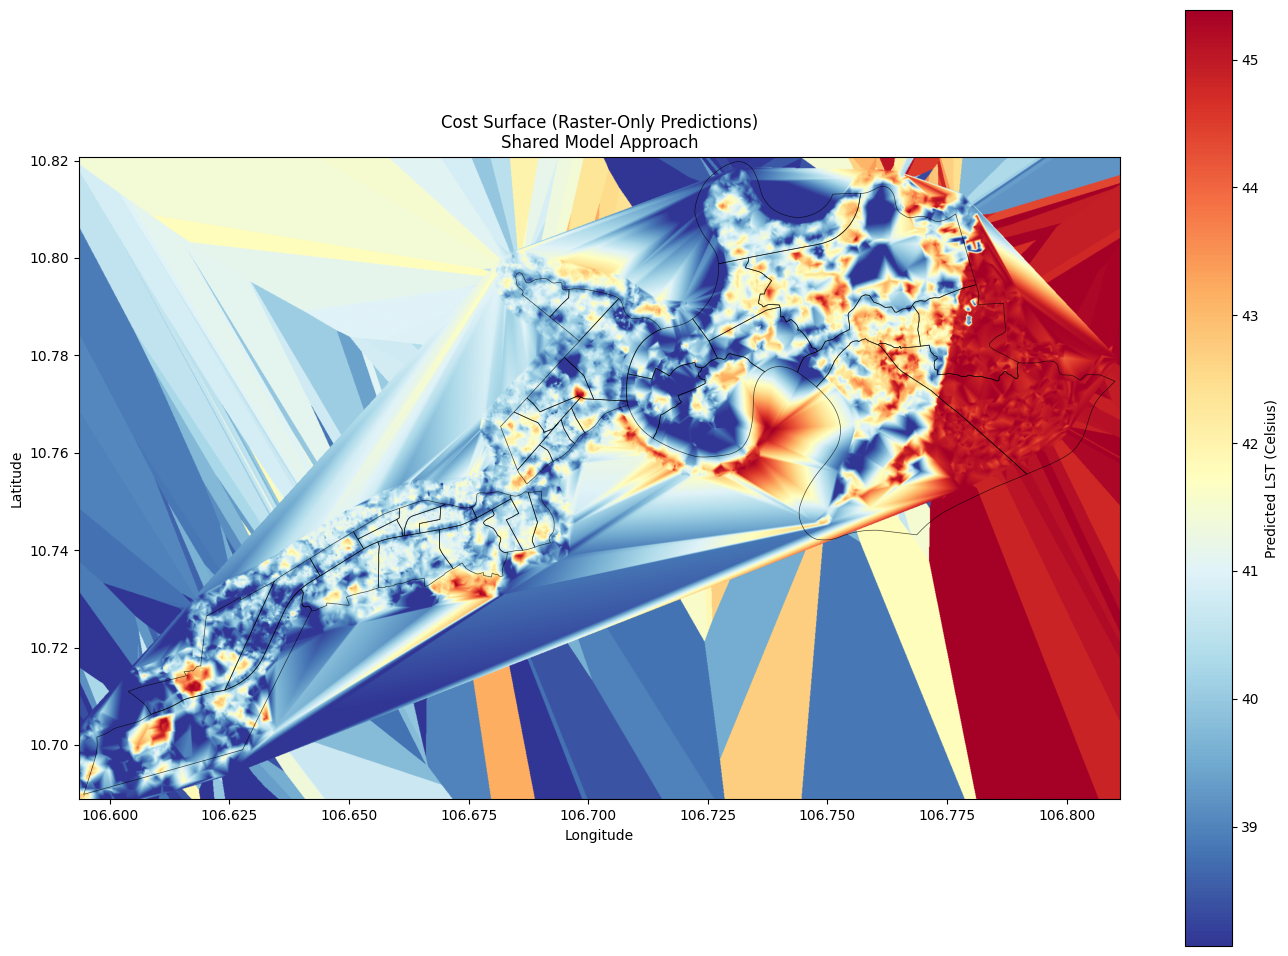

In [19]:
# Visualize cost surface with study area overlay.
fig, ax = plt.subplots(1, 1, figsize = (14, 12))

# Plot cost surface.
im = ax.imshow(
    cost_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(cost_surface, 5),
    vmax = np.nanpercentile(cost_surface, 95),
    origin = "upper"
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "black",
    linewidth = 0.5,
    alpha = 0.7
)

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Cost Surface (Raster-Only Predictions)\nShared Model Approach")

plt.tight_layout()
plt.show()

## LOAD NETWORK GRAPH

In [20]:
# Load network graph.
if NETWORK_FILE.exists():
    G = ox.load_graphml(NETWORK_FILE)
    print(f"Loaded network from file: {len(G.nodes)} nodes, {len(G.edges)} edges.")
else:
    # Download network if not available.
    print("Network file not found. Downloading from OSM.")
    study_area = gdf_wards.unary_union
    G = ox.graph_from_polygon(study_area, network_type = "walk")
    ox.save_graphml(G, NETWORK_FILE)
    print(f"Downloaded network: {len(G.nodes)} nodes, {len(G.edges)} edges.")

Loaded network from file: 12307 nodes, 33724 edges.


In [21]:
# Convert to undirected graph for routing.
G_undirected = G.to_undirected()

print(f"Undirected graph: {len(G_undirected.nodes)} nodes, {len(G_undirected.edges)} edges.")

Undirected graph: 12307 nodes, 16913 edges.


## ASSIGN HEAT WEIGHTS TO EDGES

In [22]:
# Extract node coordinates.
node_coords = {node: (data["x"], data["y"]) for node, data in G_undirected.nodes(data = True)}

print(f"Extracted coordinates for {len(node_coords)} nodes.")

Extracted coordinates for 12307 nodes.


In [23]:
# Sample LST from cost surface for each node.
print("Sampling LST values from cost surface for each node.")

node_lst = {}

for node, (lon, lat) in node_coords.items():
    # Convert coordinates to pixel indices.
    col = int((lon - raster_minx) / RESOLUTION)
    row = int((raster_maxy - lat) / RESOLUTION)

    # Check bounds.
    if 0 <= row < height and 0 <= col < width:
        lst_value = cost_surface[row, col]
        if not np.isnan(lst_value):
            node_lst[node] = lst_value
        else:
            node_lst[node] = np.nanmean(cost_surface)  # Default to mean.
    else:
        node_lst[node] = np.nanmean(cost_surface)  # Default to mean.

print(f"Assigned LST values to {len(node_lst)} nodes.")
print(f"LST range: {min(node_lst.values()):.2f} to {max(node_lst.values()):.2f}")

Sampling LST values from cost surface for each node.
Assigned LST values to 12307 nodes.
LST range: 35.87 to 46.16


In [24]:
# Assign inverted heat weights to edges.
# Dijkstra finds MINIMUM cost path.
# To find HOTTEST path, invert LST so higher temps have LOWER cost.
print("Assigning inverted heat weights to edges.")

# Get LST range for inversion.
lst_min = min(node_lst.values())
lst_max = max(node_lst.values())

for u, v, data in G_undirected.edges(data = True):
    # Get average LST of edge endpoints.
    lst_u = node_lst.get(u, np.nanmean(cost_surface))
    lst_v = node_lst.get(v, np.nanmean(cost_surface))
    avg_lst = (lst_u + lst_v) / 2

    # Invert LST: higher temperature = lower cost.
    # Inverted cost = max_LST - actual_LST + small epsilon.
    inverted_cost = lst_max - avg_lst + 0.01

    # Store both original LST and inverted cost.
    data["avg_lst"] = avg_lst
    data["heat_cost"] = inverted_cost

print("Heat weights assigned.")
print(f"Inverted cost range: {lst_max - lst_max + 0.01:.4f} (hottest) to {lst_max - lst_min + 0.01:.4f} (coolest)")

Assigning inverted heat weights to edges.


KeyboardInterrupt: 

## SELECT START AND END POINTS

In [ ]:
# Select start and end points far apart for interesting route.
# Use opposite corners of study area for maximum distance.
print("Selecting start and end points.")

# Find nodes near southwest and northeast corners.
sw_corner = (minx + 0.005, miny + 0.005)
ne_corner = (maxx - 0.005, maxy - 0.005)

# Find nearest nodes to corners.
start_node = ox.nearest_nodes(G_undirected, sw_corner[0], sw_corner[1])
end_node = ox.nearest_nodes(G_undirected, ne_corner[0], ne_corner[1])

start_coords = node_coords[start_node]
end_coords = node_coords[end_node]

print(f"Start node: {start_node} at ({start_coords[0]:.6f}, {start_coords[1]:.6f})")
print(f"End node: {end_node} at ({end_coords[0]:.6f}, {end_coords[1]:.6f})")

# Calculate straight-line distance.
from math import radians, sin, cos, sqrt, atan2

def haversine(lon1, lat1, lon2, lat2):
    R = 6371000  # Earth radius in meters.
    phi1 = radians(lat1)
    phi2 = radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1) * cos(phi2) * sin(dlambda/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

distance = haversine(start_coords[0], start_coords[1], end_coords[0], end_coords[1])
print(f"Straight-line distance: {distance:.0f} meters ({distance/1000:.2f} km)")

## RUN DIJKSTRA FOR HOTTEST PATH

In [ ]:
# Run Dijkstra algorithm with inverted heat cost.
print("Running Dijkstra algorithm to find HOTTEST path.")

try:
    hottest_path = nx.dijkstra_path(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    hottest_path_length = nx.dijkstra_path_length(
        G_undirected,
        start_node,
        end_node,
        weight = "heat_cost"
    )

    print(f"Hottest path found: {len(hottest_path)} nodes.")
    print(f"Total inverted cost: {hottest_path_length:.2f}")

except nx.NetworkXNoPath:
    print("No path found between start and end nodes.")
    hottest_path = None

In [ ]:
# Calculate path statistics.
if hottest_path:
    path_lsts = []
    path_coords = []

    for node in hottest_path:
        path_lsts.append(node_lst.get(node, np.nan))
        path_coords.append(node_coords[node])

    print("HOTTEST PATH STATISTICS")
    print(f"Number of nodes: {len(hottest_path)}")
    print(f"Average LST along path: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST along path: {np.nanmax(path_lsts):.2f} C")
    print(f"Min LST along path: {np.nanmin(path_lsts):.2f} C")
    print(f"LST std along path: {np.nanstd(path_lsts):.2f} C")

    # Calculate path length in meters.
    total_distance = 0
    for i in range(len(path_coords) - 1):
        lon1, lat1 = path_coords[i]
        lon2, lat2 = path_coords[i + 1]
        total_distance += haversine(lon1, lat1, lon2, lat2)

    print(f"Total path length: {total_distance:.0f} meters ({total_distance/1000:.2f} km)")

## COMPARE WITH SHORTEST PATH

In [ ]:
# Find shortest path for comparison.
print("Finding shortest path for comparison.")

try:
    shortest_path = nx.dijkstra_path(
        G_undirected,
        start_node,
        end_node,
        weight = "length"
    )

    # Calculate shortest path LST statistics.
    shortest_lsts = [node_lst.get(n, np.nan) for n in shortest_path]
    shortest_coords = [node_coords[n] for n in shortest_path]

    # Calculate shortest path length.
    shortest_distance = 0
    for i in range(len(shortest_coords) - 1):
        lon1, lat1 = shortest_coords[i]
        lon2, lat2 = shortest_coords[i + 1]
        shortest_distance += haversine(lon1, lat1, lon2, lat2)

    print("SHORTEST PATH STATISTICS")
    print(f"Number of nodes: {len(shortest_path)}")
    print(f"Average LST along path: {np.nanmean(shortest_lsts):.2f} C")
    print(f"Max LST along path: {np.nanmax(shortest_lsts):.2f} C")
    print(f"Path length: {shortest_distance:.0f} meters ({shortest_distance/1000:.2f} km)")

    print("")
    print("COMPARISON")
    print(f"Hottest path avg LST: {np.nanmean(path_lsts):.2f} C")
    print(f"Shortest path avg LST: {np.nanmean(shortest_lsts):.2f} C")
    print(f"LST difference: {np.nanmean(path_lsts) - np.nanmean(shortest_lsts):.2f} C")
    print(f"Distance difference: {total_distance - shortest_distance:.0f} meters")

except nx.NetworkXNoPath:
    print("No shortest path found.")
    shortest_path = None

## VISUALIZE HOTTEST ROUTE

In [ ]:
# Create visualization of hottest route over cost surface.
fig, ax = plt.subplots(1, 1, figsize = (16, 14))

# Plot cost surface.
im = ax.imshow(
    cost_surface,
    extent = [raster_minx, raster_maxx, raster_miny, raster_maxy],
    cmap = "RdYlBu_r",
    vmin = np.nanpercentile(cost_surface, 5),
    vmax = np.nanpercentile(cost_surface, 95),
    origin = "upper",
    alpha = 0.8
)

# Overlay ward boundaries.
gdf_wards.boundary.plot(
    ax = ax,
    color = "gray",
    linewidth = 0.5,
    alpha = 0.5
)

# Plot shortest path for comparison.
if shortest_path:
    short_x = [node_coords[n][0] for n in shortest_path]
    short_y = [node_coords[n][1] for n in shortest_path]

    ax.plot(
        short_x,
        short_y,
        color = "cyan",
        linewidth = 2,
        linestyle = "--",
        label = f"Shortest Route (avg LST: {np.nanmean(shortest_lsts):.1f}C)",
        zorder = 9,
        alpha = 0.7
    )

# Plot hottest path.
if hottest_path:
    path_x = [node_coords[n][0] for n in hottest_path]
    path_y = [node_coords[n][1] for n in hottest_path]

    ax.plot(
        path_x,
        path_y,
        color = "magenta",
        linewidth = 3,
        label = f"Hottest Route (avg LST: {np.nanmean(path_lsts):.1f}C)",
        zorder = 10
    )

    # Mark start and end.
    ax.scatter(
        [start_coords[0]],
        [start_coords[1]],
        c = "lime",
        s = 200,
        marker = "o",
        edgecolor = "black",
        linewidth = 2,
        label = "Start",
        zorder = 11
    )

    ax.scatter(
        [end_coords[0]],
        [end_coords[1]],
        c = "red",
        s = 200,
        marker = "X",
        edgecolor = "black",
        linewidth = 2,
        label = "End",
        zorder = 11
    )

cbar = plt.colorbar(im, ax = ax, label = "Predicted LST (Celsius)", shrink = 0.7)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("HOTTEST Route (Shared Model Approach)\nDijkstra with Inverted Heat Cost vs Shortest Path")
ax.legend(loc = "upper right")

plt.tight_layout()
plt.show()

## SAVE HOTTEST ROUTE

In [ ]:
# Save hottest route as GeoJSON.
if hottest_path:
    # Create LineString geometry.
    route_line = LineString(path_coords)

    # Create GeoDataFrame.
    gdf_route = gpd.GeoDataFrame(
        {
            "route_type": ["hottest_shared"],
            "num_nodes": [len(hottest_path)],
            "avg_lst": [np.nanmean(path_lsts)],
            "max_lst": [np.nanmax(path_lsts)],
            "min_lst": [np.nanmin(path_lsts)],
            "length_m": [total_distance],
        },
        geometry = [route_line],
        crs = "EPSG:4326"
    )

    # Save to file.
    gdf_route.to_file(HOTTEST_ROUTE, driver = "GeoJSON")

    print(f"Hottest route saved to {HOTTEST_ROUTE}")
    print(gdf_route)

## LST PROFILE ALONG PATH

In [ ]:
# Plot LST profile along hottest path.
if hottest_path:
    fig, ax = plt.subplots(1, 1, figsize = (14, 5))

    # Calculate cumulative distance along path.
    cumulative_dist = [0]
    for i in range(len(path_coords) - 1):
        lon1, lat1 = path_coords[i]
        lon2, lat2 = path_coords[i + 1]
        segment_dist = haversine(lon1, lat1, lon2, lat2)
        cumulative_dist.append(cumulative_dist[-1] + segment_dist)

    # Convert to kilometers.
    cumulative_dist_km = [d / 1000 for d in cumulative_dist]

    # Plot LST profile.
    ax.fill_between(
        cumulative_dist_km,
        path_lsts,
        alpha = 0.3,
        color = "red"
    )
    ax.plot(
        cumulative_dist_km,
        path_lsts,
        color = "red",
        linewidth = 2,
        label = "Hottest Path"
    )

    # Add mean line.
    ax.axhline(
        np.nanmean(path_lsts),
        color = "red",
        linestyle = "--",
        alpha = 0.7,
        label = f"Mean: {np.nanmean(path_lsts):.1f}C"
    )

    # Plot shortest path LST if available.
    if shortest_path:
        short_cumulative = [0]
        for i in range(len(shortest_coords) - 1):
            lon1, lat1 = shortest_coords[i]
            lon2, lat2 = shortest_coords[i + 1]
            segment_dist = haversine(lon1, lat1, lon2, lat2)
            short_cumulative.append(short_cumulative[-1] + segment_dist)

        short_cumulative_km = [d / 1000 for d in short_cumulative]

        ax.plot(
            short_cumulative_km,
            shortest_lsts,
            color = "cyan",
            linewidth = 2,
            linestyle = "--",
            alpha = 0.7,
            label = f"Shortest Path (mean: {np.nanmean(shortest_lsts):.1f}C)"
        )

    ax.set_xlabel("Distance along path (km)")
    ax.set_ylabel("Predicted LST (Celsius)")
    ax.set_title("LST Profile Along Hottest Path")
    ax.legend()
    ax.grid(alpha = 0.3)

    plt.tight_layout()
    plt.show()

## SUMMARY

In [ ]:
print("SHARED MODEL DIJKSTRA SUMMARY")
print("")
print("Approach: Use raster-only predictions for uniform coverage across study area.")
print("")
print("OUTPUTS")
print(f"Cost surface: {COST_SURFACE}")
print(f"Hottest route: {HOTTEST_ROUTE}")
print("")
if hottest_path:
    print("HOTTEST ROUTE STATISTICS")
    print(f"Path length: {total_distance/1000:.2f} km")
    print(f"Average LST: {np.nanmean(path_lsts):.2f} C")
    print(f"Max LST: {np.nanmax(path_lsts):.2f} C")
    print(f"Min LST: {np.nanmin(path_lsts):.2f} C")
    print("")
    if shortest_path:
        print("COMPARISON WITH SHORTEST PATH")
        print(f"Shortest path avg LST: {np.nanmean(shortest_lsts):.2f} C")
        print(f"LST gain by taking hottest: +{np.nanmean(path_lsts) - np.nanmean(shortest_lsts):.2f} C")
        print(f"Distance penalty: +{(total_distance - shortest_distance)/1000:.2f} km")